# So Sanh Mo Hinh: UNet-ResNet50 vs Swin-UNet

**Bai toan**: Skin Lesion Segmentation — ISIC 2018 Task 1  
**Muc tieu**: So sanh hieu nang giua kien truc **CNN** (UNet-ResNet50) va **Vision Transformer** (Swin-UNet) tren cung tap du lieu va dieu kien huan luyen.

| | UNet-ResNet50 | Swin-UNet |
|---|---|---|
| **Kien truc** | CNN (Encoder-Decoder) | Vision Transformer |
| **Backbone** | ResNet-50 (ImageNet) | Swin Transformer (ImageNet-22k) |
| **Framework** | PyTorch + SMP | PyTorch |

In [1]:
# --- Imports & Setup ---
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# Resolve project root
PROJECT_ROOT = Path().resolve()
if (PROJECT_ROOT / 'src').exists():
    pass
elif (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'comparison'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Matplotlib style
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
})

# ── Color palette ──
C_UNET = '#2196F3'   # Blue for UNet-ResNet50
C_SWIN = '#9C27B0'   # Purple for Swin-UNet
C_UNET_LIGHT = '#90CAF9'
C_SWIN_LIGHT = '#CE93D8'

print(f'Project root: {PROJECT_ROOT}')
print(f'Outputs dir : {OUTPUTS_DIR}')

Project root: C:\Users\yello\Coding\Python\Projects\Deep Learning\Skin-Lesion-Segmentation
Outputs dir : C:\Users\yello\Coding\Python\Projects\Deep Learning\Skin-Lesion-Segmentation\outputs


In [2]:
# --- Load Data for Both Models ---

models_info = {}

for model_key, model_label in [('unet_resnet50', 'UNet-ResNet50'), ('swin_unet', 'Swin-UNet')]:
    # Training history
    hist_files = sorted(OUTPUTS_DIR.glob(f'history_{model_key}_*.json'))
    assert hist_files, f'No training history found for {model_key}!'
    with hist_files[-1].open('r', encoding='utf-8') as f:
        hist_data = json.load(f)

    # Evaluation results
    eval_path = OUTPUTS_DIR / f'eval_{model_key}_test.json'
    with eval_path.open('r', encoding='utf-8') as f:
        eval_data = json.load(f)

    # Per-sample CSV
    csv_path = OUTPUTS_DIR / f'eval_{model_key}_test_per_sample.csv'
    df_samples = pd.read_csv(csv_path)

    history = hist_data['history']
    epochs = list(range(1, len(history['train_loss']) + 1))
    best_epoch_idx = int(np.argmax(history['val_dice']))

    models_info[model_key] = {
        'label': model_label,
        'hist_data': hist_data,
        'history': history,
        'epochs': epochs,
        'eval_data': eval_data,
        'df_samples': df_samples,
        'args': hist_data['args'],
        'best_epoch': best_epoch_idx + 1,
        'best_dice': hist_data['best_dice'],
        'freeze_epochs': hist_data['args'].get('freeze_encoder', 5),
    }

    print(f'\n--- {model_label} ---')
    print(f'  Epochs completed : {hist_data["epochs_completed"]}')
    print(f'  Best Val Dice    : {hist_data["best_dice"]:.4f} (epoch {best_epoch_idx + 1})')
    print(f'  Test samples     : {eval_data["num_samples"]}')
    print(f'  Training time    : {sum(history["epoch_time"])/3600:.1f} hours')

unet = models_info['unet_resnet50']
swin = models_info['swin_unet']


--- UNet-ResNet50 ---
  Epochs completed : 38
  Best Val Dice    : 0.8918 (epoch 23)
  Test samples     : 1000
  Training time    : 9.9 hours

--- Swin-UNet ---
  Epochs completed : 27
  Best Val Dice    : 0.8971 (epoch 12)
  Test samples     : 1000
  Training time    : 8.0 hours


---
## 1. So Sanh Cau Hinh Huan Luyen

Bang doi chieu cac tham so huan luyen giua hai mo hinh.

In [3]:
# --- Config Comparison Table ---
def fmt_time(seconds):
    return f'{seconds/3600:.1f} hours'

config_params = [
    'Model Architecture', 'Encoder Backbone', 'Pretrained Weights',
    'Input Size', 'Batch Size', 'Max Epochs', 'Epochs Completed',
    'Encoder Frozen For', 'Decoder LR', 'Encoder LR', 'Weight Decay',
    'Loss Function', 'Patience', 'Device',
    'Best Val Dice', 'Total Training Time',
]

def get_config_values(m):
    a, h, hd = m['args'], m['history'], m['hist_data']
    is_unet_resnet = (a['model'] == 'unet_resnet50')
    model_name = 'UNet' if is_unet_resnet else 'Swin-UNet'
    backbone = 'ResNet-50' if is_unet_resnet else 'Swin Transformer'
    pretrained = 'ImageNet' if is_unet_resnet else 'ImageNet-22k'
    return [
        model_name, backbone, pretrained,
        f"{a['img_size']}x{a['img_size']}", a['batch_size'],
        a['epochs'], hd['epochs_completed'],
        f"{a['freeze_encoder']} epochs",
        a['lr'], a['encoder_lr'], a['weight_decay'],
        'BCE-Dice', a['patience'], hd['device'],
        f"{hd['best_dice']:.4f}",
        fmt_time(sum(h['epoch_time'])),
    ]

df_cfg = pd.DataFrame({
    'Parameter': config_params,
    'UNet-ResNet50': get_config_values(unet),
    'Swin-UNet': get_config_values(swin),
})

# Highlight differences
def highlight_diff(row):
    if row['UNet-ResNet50'] != row['Swin-UNet']:
        return ['', 'background-color: #E3F2FD', 'background-color: #F3E5F5']
    return ['', '', '']

styled = df_cfg.style.apply(highlight_diff, axis=1).set_properties(**{
    'text-align': 'center', 'font-size': '12px',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#37474F'), ('color', 'white'),
                                  ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px 12px')]},
]).hide(axis='index')

display(HTML('<h3>Training Configuration Comparison</h3>'))
display(styled)

Parameter,UNet-ResNet50,Swin-UNet
Model Architecture,UNet,Swin-UNet
Encoder Backbone,ResNet-50,Swin Transformer
Pretrained Weights,ImageNet,ImageNet-22k
Input Size,256x256,256x256
Batch Size,16,4
Max Epochs,50,50
Epochs Completed,38,27
Encoder Frozen For,5 epochs,5 epochs
Decoder LR,0.000100,0.000100
Encoder LR,0.000010,0.000010


---
## 2. Training Curves So Sanh

So sanh qua trinh hoc giua hai mo hinh: Loss, Dice va IoU tren Validation set.

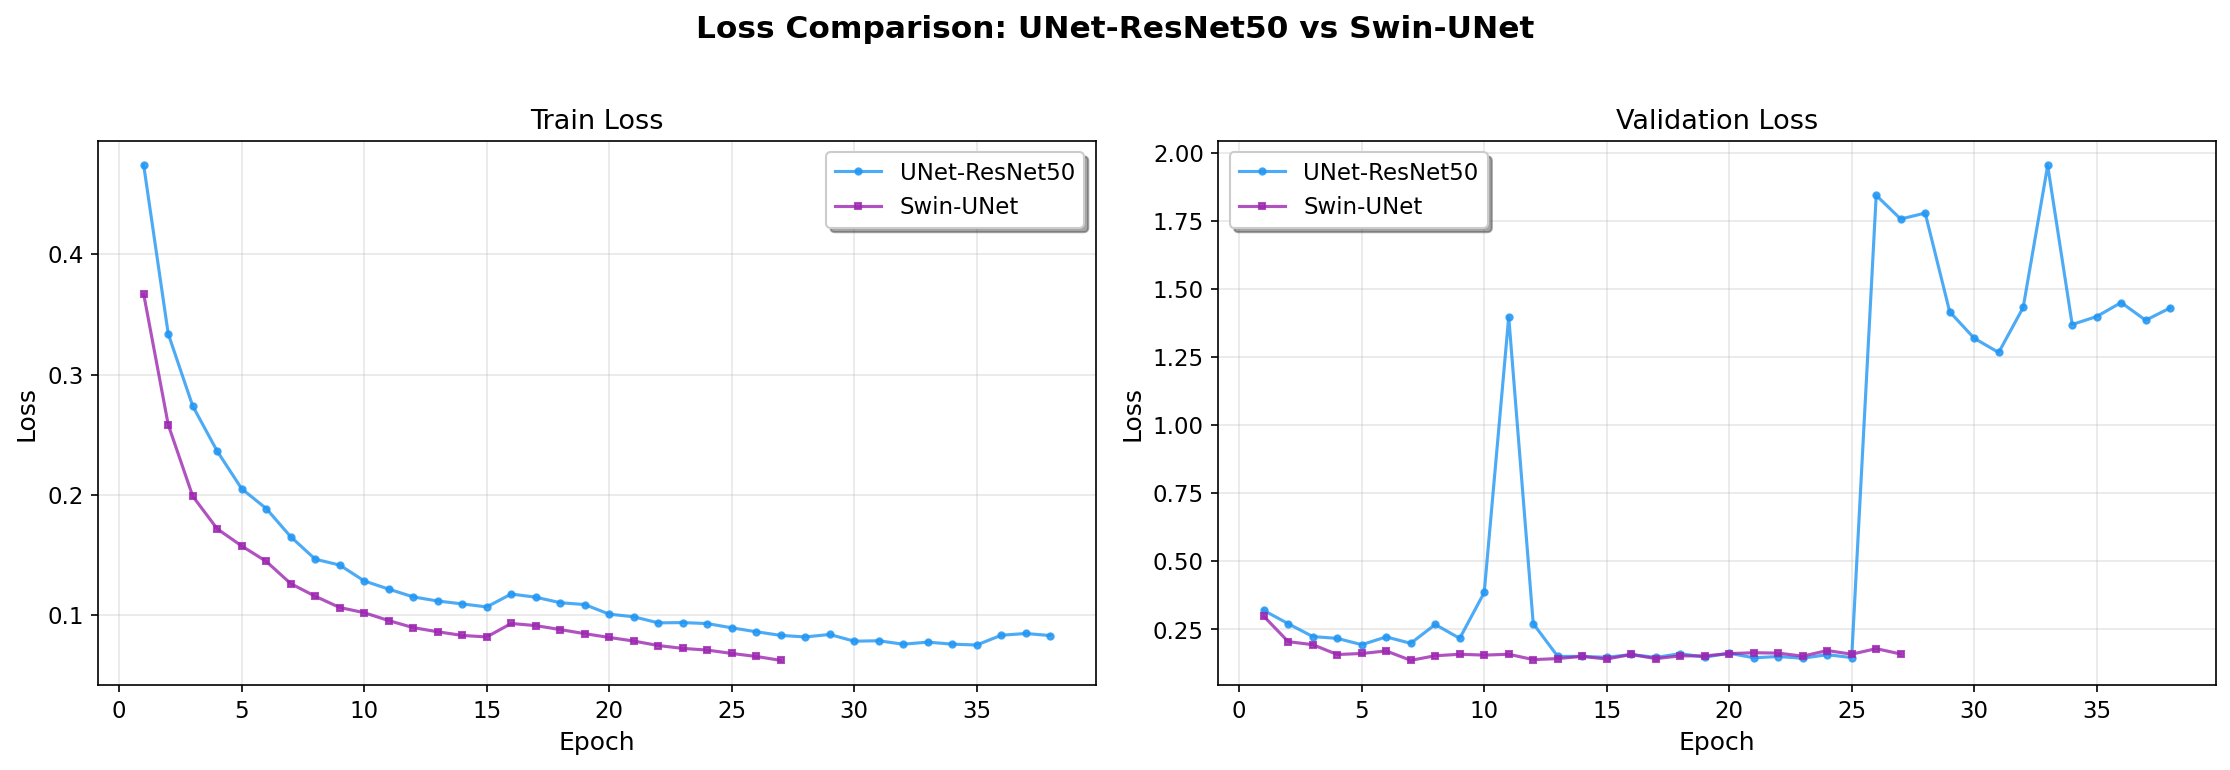

In [4]:
# --- Training & Validation Loss Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train Loss
ax = axes[0]
ax.plot(unet['epochs'], unet['history']['train_loss'], 'o-', label='UNet-ResNet50',
        color=C_UNET, markersize=3, linewidth=1.5, alpha=0.8)
ax.plot(swin['epochs'], swin['history']['train_loss'], 's-', label='Swin-UNet',
        color=C_SWIN, markersize=3, linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train Loss')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Val Loss
ax = axes[1]
ax.plot(unet['epochs'], unet['history']['val_loss'], 'o-', label='UNet-ResNet50',
        color=C_UNET, markersize=3, linewidth=1.5, alpha=0.8)
ax.plot(swin['epochs'], swin['history']['val_loss'], 's-', label='Swin-UNet',
        color=C_SWIN, markersize=3, linewidth=1.5, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Loss Comparison: UNet-ResNet50 vs Swin-UNet',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '01_loss_comparison.png')
plt.show()

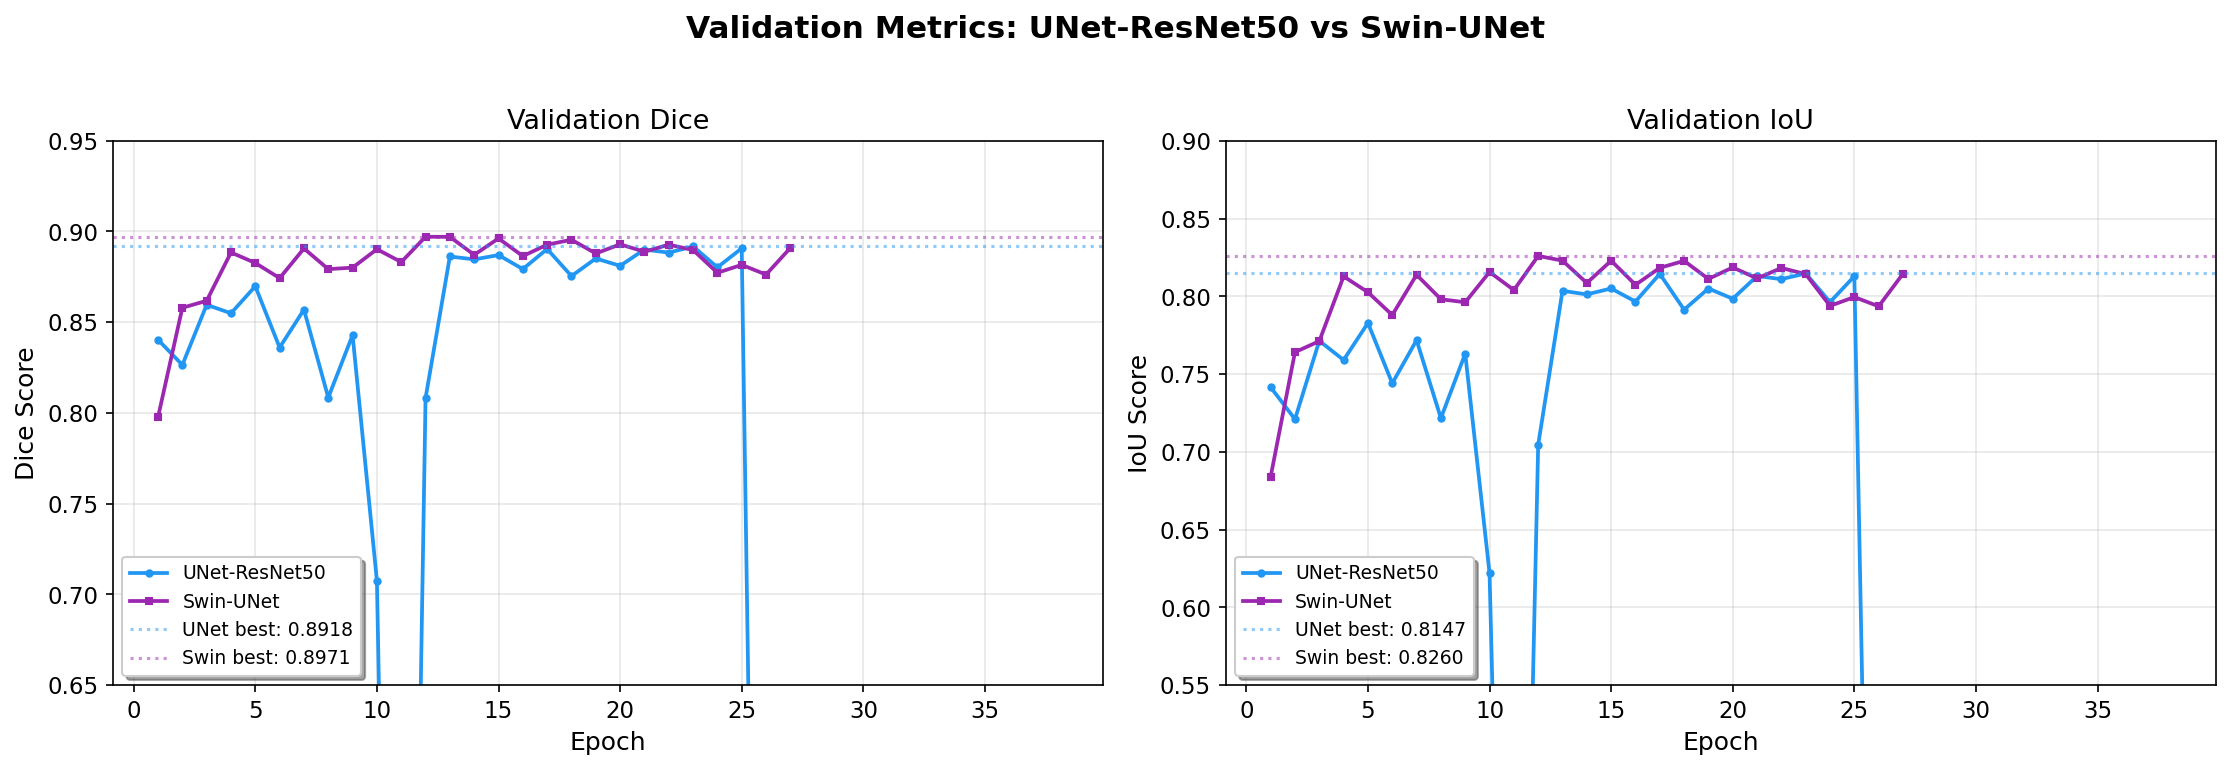

In [5]:
# --- Validation Dice & IoU Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Val Dice
ax = axes[0]
ax.plot(unet['epochs'], unet['history']['val_dice'], 'o-', label='UNet-ResNet50',
        color=C_UNET, markersize=3, linewidth=1.8)
ax.plot(swin['epochs'], swin['history']['val_dice'], 's-', label='Swin-UNet',
        color=C_SWIN, markersize=3, linewidth=1.8)
ax.axhline(y=unet['best_dice'], color=C_UNET, linestyle=':', alpha=0.5,
           label=f'UNet best: {unet["best_dice"]:.4f}')
ax.axhline(y=swin['best_dice'], color=C_SWIN, linestyle=':', alpha=0.5,
           label=f'Swin best: {swin["best_dice"]:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.set_title('Validation Dice')
ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.65, 0.95)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Val IoU
ax = axes[1]
ax.plot(unet['epochs'], unet['history']['val_iou'], 'o-', label='UNet-ResNet50',
        color=C_UNET, markersize=3, linewidth=1.8)
ax.plot(swin['epochs'], swin['history']['val_iou'], 's-', label='Swin-UNet',
        color=C_SWIN, markersize=3, linewidth=1.8)
unet_best_iou = max(unet['history']['val_iou'])
swin_best_iou = max(swin['history']['val_iou'])
ax.axhline(y=unet_best_iou, color=C_UNET, linestyle=':', alpha=0.5,
           label=f'UNet best: {unet_best_iou:.4f}')
ax.axhline(y=swin_best_iou, color=C_SWIN, linestyle=':', alpha=0.5,
           label=f'Swin best: {swin_best_iou:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU Score')
ax.set_title('Validation IoU')
ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.55, 0.90)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Validation Metrics: UNet-ResNet50 vs Swin-UNet',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '02_dice_iou_comparison.png')
plt.show()

### Nhan xet:
- **Toc do hoi tu**: Swin-UNet dat Dice cao hon tu rat som, cho thay Swin Transformer pretrained trich xuat dac trung toan cuc (global context) hieu qua hon ResNet-50 cho bai toan phan vung.
- **Best Val Dice**: Swin-UNet dat dinh cao hon UNet-ResNet50, cho thay kien truc Transformer co loi the trong viec nhan dien bien ton thuong da.
- **Overfitting**: UNet-ResNet50 co xu huong overfit nhieu hon (Val Loss tang dan sau epoch 25), trong khi Swin-UNet on dinh hon.

---
## 3. Thoi Gian Huan Luyen

So sanh chi phi tinh toan giua hai kien truc.

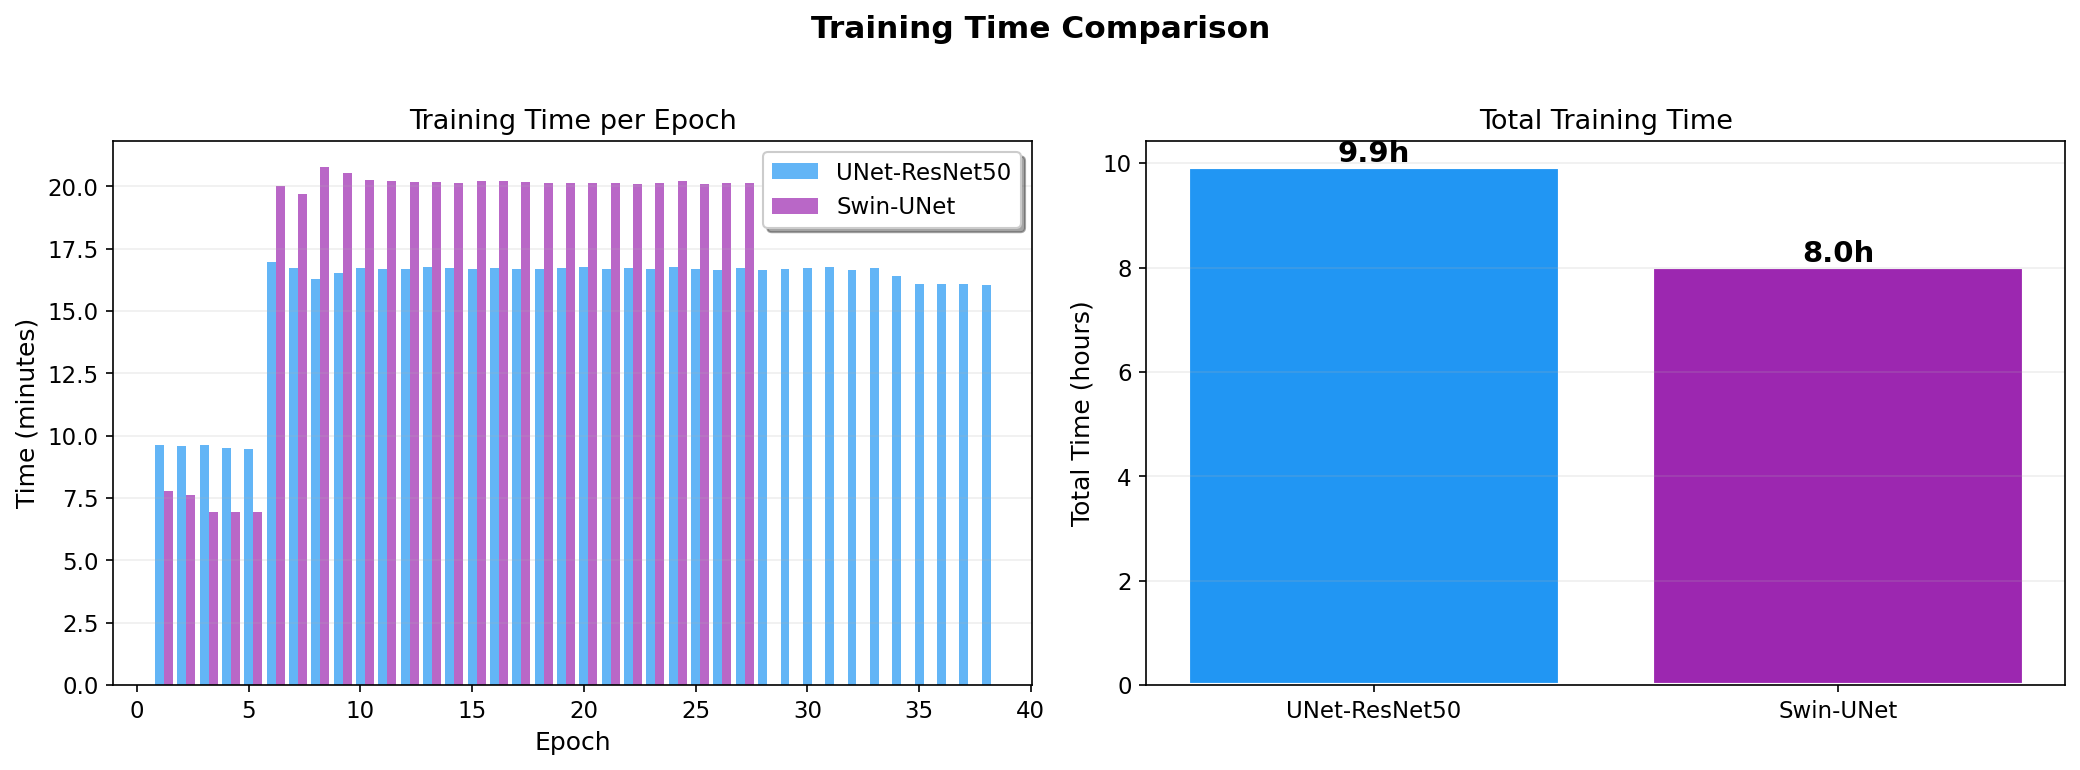

UNet-ResNet50: avg 15.7 min/epoch, total 9.9 hours (38 epochs)
Swin-UNet    : avg 17.8 min/epoch, total 8.0 hours (27 epochs)
Swin-UNet cham hon 1.1x per epoch


In [6]:
# --- Training Time Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-epoch time comparison
ax = axes[0]
unet_times = [t / 60 for t in unet['history']['epoch_time']]
swin_times = [t / 60 for t in swin['history']['epoch_time']]

ax.bar(unet['epochs'], unet_times, color=C_UNET, alpha=0.7, label='UNet-ResNet50', width=0.4)
swin_x = [e + 0.4 for e in swin['epochs']]
ax.bar(swin_x, swin_times, color=C_SWIN, alpha=0.7, label='Swin-UNet', width=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (minutes)')
ax.set_title('Training Time per Epoch')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.2, axis='y')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Total time comparison
ax = axes[1]
total_unet = sum(unet['history']['epoch_time']) / 3600
total_swin = sum(swin['history']['epoch_time']) / 3600
avg_unet = np.mean(unet_times)
avg_swin = np.mean(swin_times)

bars = ax.bar(['UNet-ResNet50', 'Swin-UNet'], [total_unet, total_swin],
              color=[C_UNET, C_SWIN], edgecolor='white', linewidth=2)
for bar, val in zip(bars, [total_unet, total_swin]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.1f}h', ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Total Time (hours)')
ax.set_title('Total Training Time')
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Training Time Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '03_training_time.png')
plt.show()

print(f'UNet-ResNet50: avg {avg_unet:.1f} min/epoch, total {total_unet:.1f} hours ({len(unet_times)} epochs)')
print(f'Swin-UNet    : avg {avg_swin:.1f} min/epoch, total {total_swin:.1f} hours ({len(swin_times)} epochs)')
print(f'Swin-UNet cham hon {avg_swin/avg_unet:.1f}x per epoch')

---
## 4. Ket Qua Test Set

So sanh tat ca cac chi so danh gia tren tap kiem thu (1,000 anh).

In [7]:
# --- Test Metrics Comparison Table ---
metric_display = {
    'dice': 'Dice Score (F1)',
    'iou': 'IoU (Jaccard)',
    'accuracy': 'Pixel Accuracy',
    'sensitivity': 'Sensitivity (Recall)',
    'specificity': 'Specificity',
}

rows = []
for key, name in metric_display.items():
    u_val = unet['eval_data']['aggregated_metrics'][key]
    s_val = swin['eval_data']['aggregated_metrics'][key]
    diff = s_val - u_val
    winner = 'Swin-UNet' if diff > 0 else ('UNet-ResNet50' if diff < 0 else 'Tie')
    rows.append({
        'Metric': name,
        'UNet-ResNet50': f'{u_val:.4f}',
        'Swin-UNet': f'{s_val:.4f}',
        'Difference': f'{diff:+.4f}',
        'Winner': winner,
    })

df_compare = pd.DataFrame(rows)

def color_winner(val):
    if val == 'Swin-UNet':
        return 'color: #7B1FA2; font-weight: bold'
    elif val == 'UNet-ResNet50':
        return 'color: #1565C0; font-weight: bold'
    return ''

def color_diff(val):
    try:
        v = float(val)
        if v > 0:
            return 'color: #2E7D32; font-weight: bold'
        elif v < 0:
            return 'color: #C62828; font-weight: bold'
    except ValueError:
        pass
    return ''

styled = df_compare.style.map(color_winner, subset=['Winner']) \
    .map(color_diff, subset=['Difference']) \
    .set_properties(**{'text-align': 'center', 'font-size': '13px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#37474F'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center'),
                                      ('padding', '8px 15px')]},
        {'selector': 'td', 'props': [('padding', '8px 15px')]},
    ]).hide(axis='index')

display(HTML('<h3>Test Set Metrics Comparison (n = 1,000)</h3>'))
display(styled)

Metric,UNet-ResNet50,Swin-UNet,Difference,Winner
Dice Score (F1),0.8721,0.8920,+0.0199,Swin-UNet
IoU (Jaccard),0.7941,0.8175,+0.0234,Swin-UNet
Pixel Accuracy,0.9276,0.9387,+0.0110,Swin-UNet
Sensitivity (Recall),0.9268,0.9612,+0.0344,Swin-UNet
Specificity,0.9354,0.9138,-0.0216,UNet-ResNet50


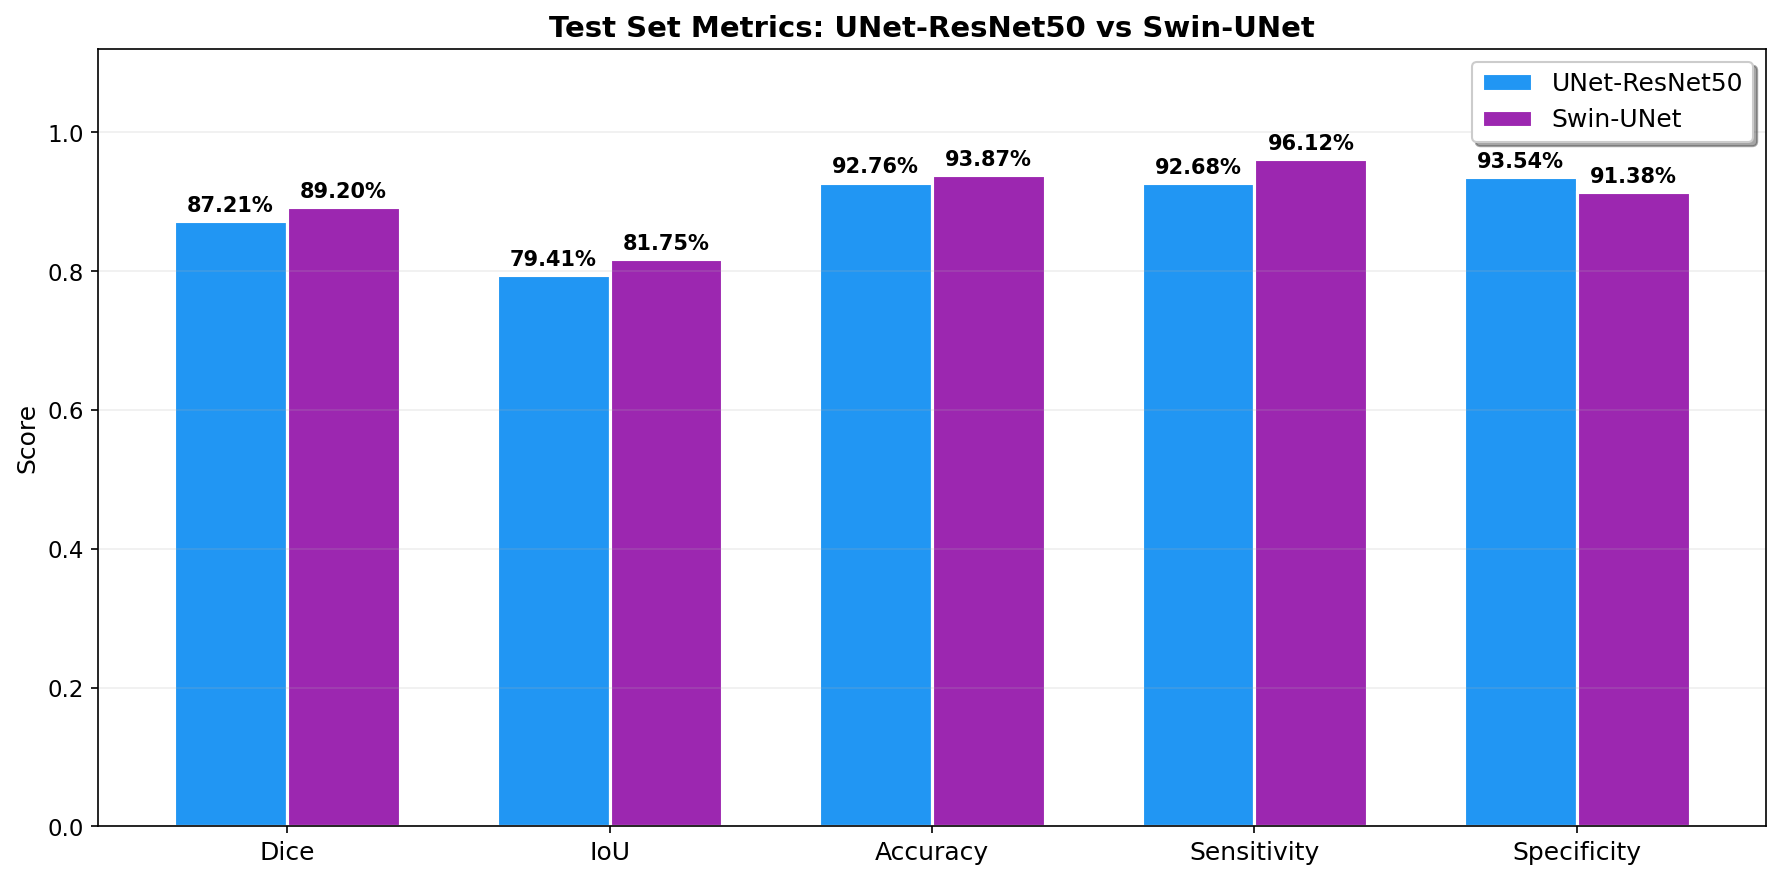

In [8]:
# --- Grouped Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

metric_names = ['Dice', 'IoU', 'Accuracy', 'Sensitivity', 'Specificity']
metric_keys = ['dice', 'iou', 'accuracy', 'sensitivity', 'specificity']

unet_vals = [unet['eval_data']['aggregated_metrics'][k] for k in metric_keys]
swin_vals = [swin['eval_data']['aggregated_metrics'][k] for k in metric_keys]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, unet_vals, width, label='UNet-ResNet50',
               color=C_UNET, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, swin_vals, width, label='Swin-UNet',
               color=C_SWIN, edgecolor='white', linewidth=1.5)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.008,
                f'{height:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Test Set Metrics: UNet-ResNet50 vs Swin-UNet', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
fig.savefig(REPORT_DIR / '04_metrics_comparison.png')
plt.show()

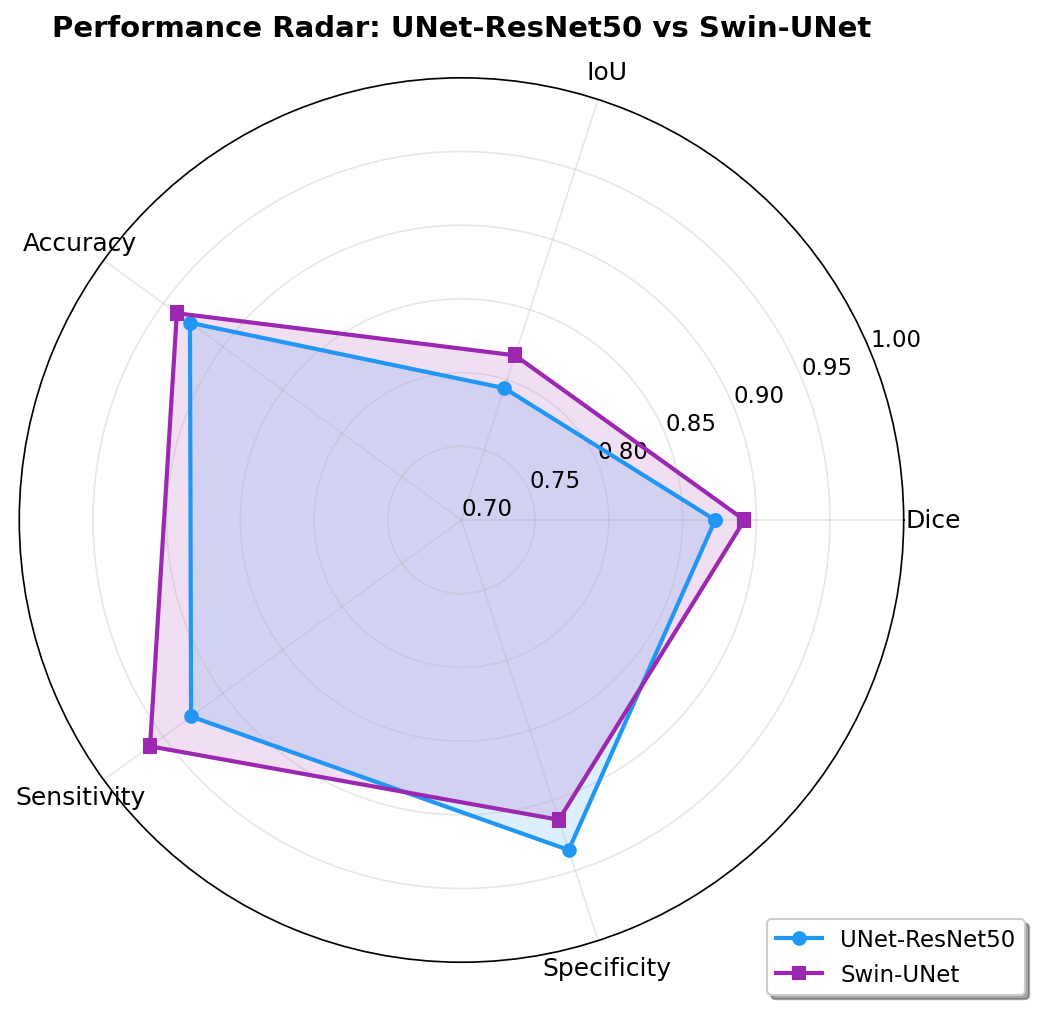

In [9]:
# --- Radar Chart ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

labels = ['Dice', 'IoU', 'Accuracy', 'Sensitivity', 'Specificity']
keys = ['dice', 'iou', 'accuracy', 'sensitivity', 'specificity']
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

unet_vals = [unet['eval_data']['aggregated_metrics'][k] for k in keys]
swin_vals = [swin['eval_data']['aggregated_metrics'][k] for k in keys]
unet_vals += unet_vals[:1]
swin_vals += swin_vals[:1]

ax.fill(angles, unet_vals, alpha=0.15, color=C_UNET)
ax.plot(angles, unet_vals, 'o-', linewidth=2, color=C_UNET,
        label='UNet-ResNet50', markersize=6)

ax.fill(angles, swin_vals, alpha=0.15, color=C_SWIN)
ax.plot(angles, swin_vals, 's-', linewidth=2, color=C_SWIN,
        label='Swin-UNet', markersize=6)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0.7, 1.0)
ax.set_title('Performance Radar: UNet-ResNet50 vs Swin-UNet',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.15, -0.05),
          fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(REPORT_DIR / '05_radar_chart.png')
plt.show()

---
## 5. Phan Phoi Diem So Tren Tung Mau

So sanh histogram cua Dice, IoU, Accuracy giua hai mo hinh tren tap test.

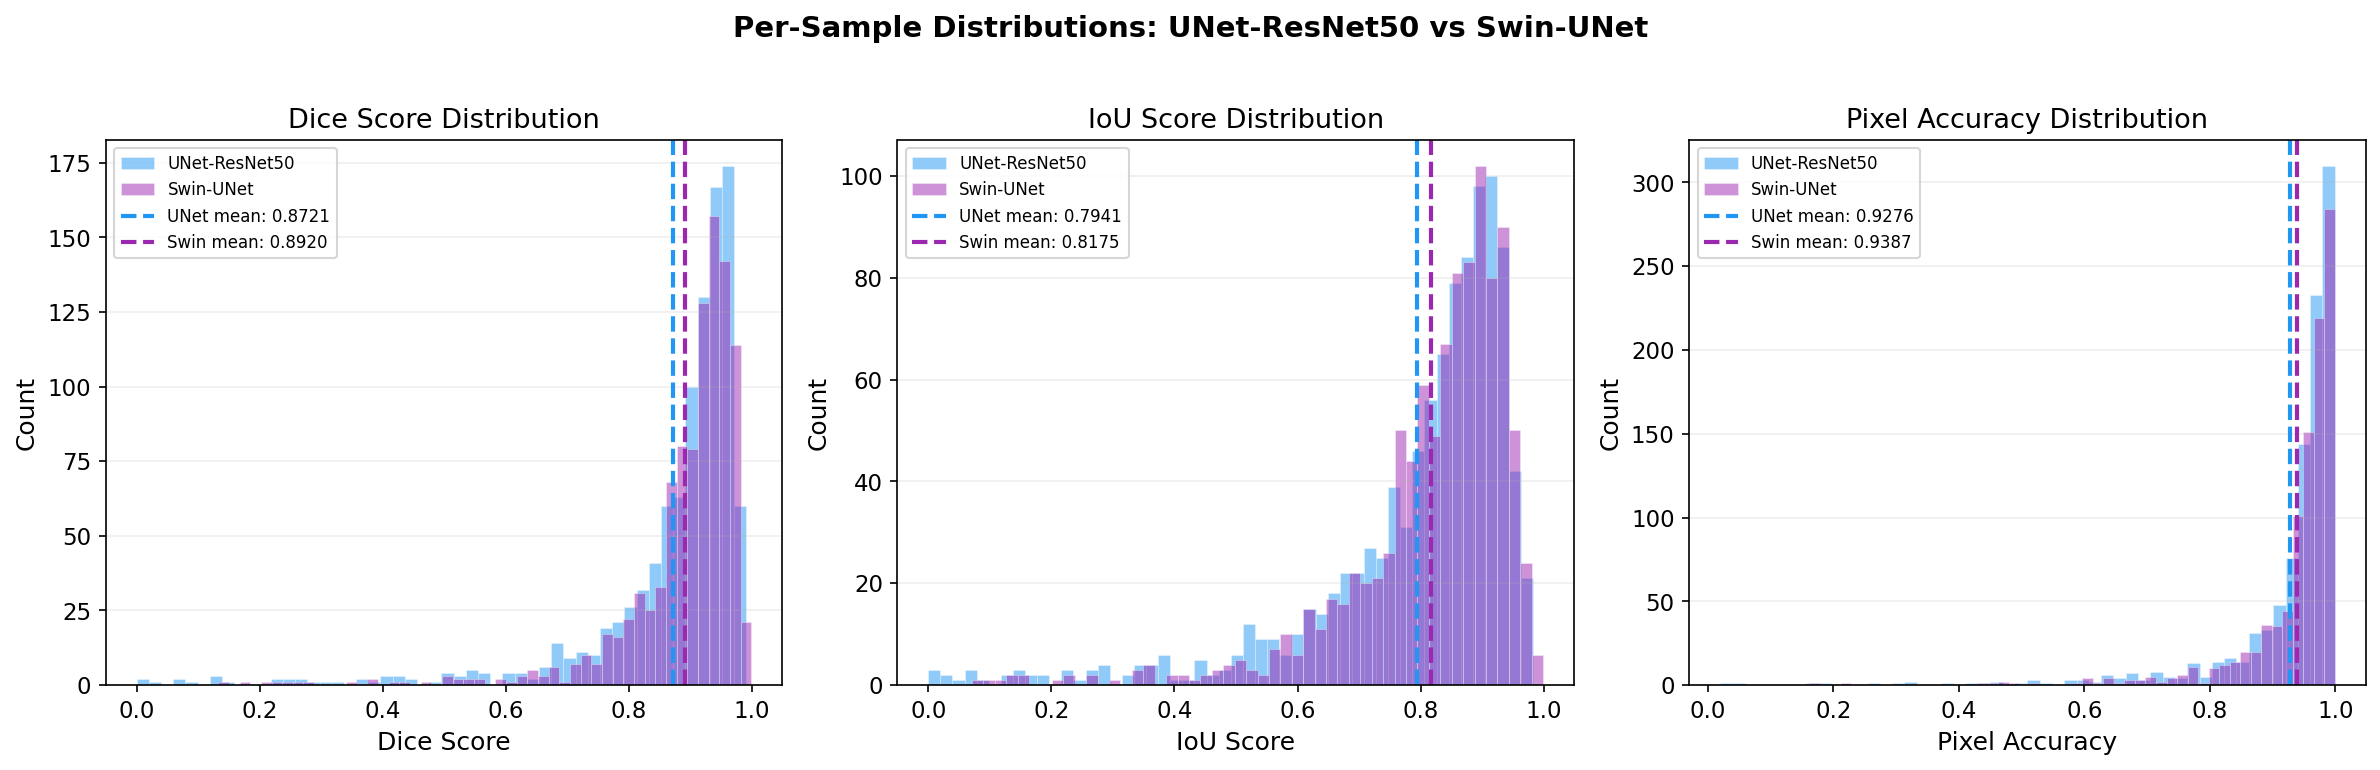

In [10]:
# --- Overlaid Histograms ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in [
    (axes[0], 'dice', 'Dice Score'),
    (axes[1], 'iou', 'IoU Score'),
    (axes[2], 'accuracy', 'Pixel Accuracy'),
]:
    u_data = unet['df_samples'][col].values
    s_data = swin['df_samples'][col].values

    ax.hist(u_data, bins=50, color=C_UNET, alpha=0.5, label='UNet-ResNet50',
            edgecolor='white', linewidth=0.3)
    ax.hist(s_data, bins=50, color=C_SWIN, alpha=0.5, label='Swin-UNet',
            edgecolor='white', linewidth=0.3)

    # Mean lines
    ax.axvline(x=np.mean(u_data), color=C_UNET, linestyle='--', linewidth=2,
               label=f'UNet mean: {np.mean(u_data):.4f}')
    ax.axvline(x=np.mean(s_data), color=C_SWIN, linestyle='--', linewidth=2,
               label=f'Swin mean: {np.mean(s_data):.4f}')

    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Distribution')
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Per-Sample Distributions: UNet-ResNet50 vs Swin-UNet',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '06_distributions.png')
plt.show()

C:\Users\yello\AppData\Local\Temp\ipykernel_10736\3702721492.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['UNet', 'Swin'], patch_artist=True,
C:\Users\yello\AppData\Local\Temp\ipykernel_10736\3702721492.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['UNet', 'Swin'], patch_artist=True,
C:\Users\yello\AppData\Local\Temp\ipykernel_10736\3702721492.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['UNet', 'Swin'], patch_artist=True,
C:\Users\yello\AppData\Local\Temp\ipykernel_10736\3702721492.py:12: MatplotlibDepreca

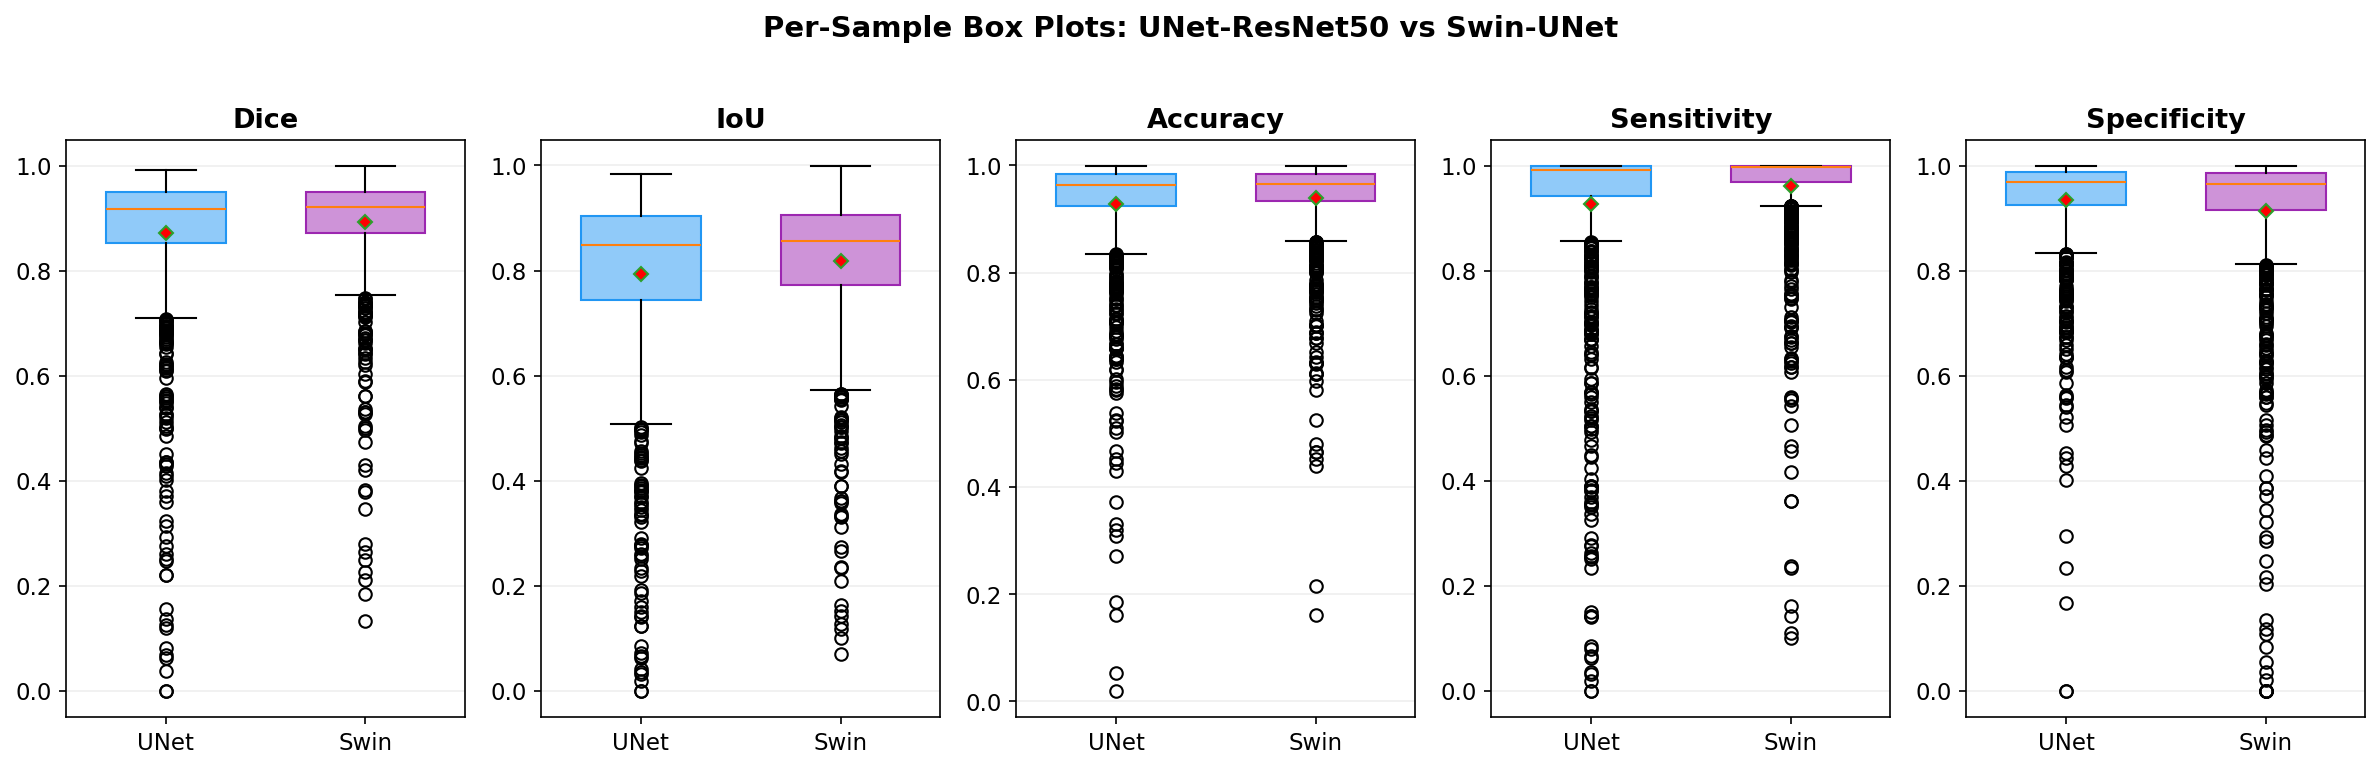

In [11]:
# --- Box Plot Comparison ---
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, col, title in [
    (axes[0], 'dice', 'Dice'),
    (axes[1], 'iou', 'IoU'),
    (axes[2], 'accuracy', 'Accuracy'),
    (axes[3], 'sensitivity', 'Sensitivity'),
    (axes[4], 'specificity', 'Specificity'),
]:
    data = [unet['df_samples'][col].values, swin['df_samples'][col].values]
    bp = ax.boxplot(data, labels=['UNet', 'Swin'], patch_artist=True,
                    widths=0.6, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
    bp['boxes'][0].set_facecolor(C_UNET_LIGHT)
    bp['boxes'][1].set_facecolor(C_SWIN_LIGHT)
    bp['boxes'][0].set_edgecolor(C_UNET)
    bp['boxes'][1].set_edgecolor(C_SWIN)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Per-Sample Box Plots: UNet-ResNet50 vs Swin-UNet',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '07_boxplots.png')
plt.show()

---
## 6. Kiem Dinh Thong Ke

Su dung **Wilcoxon Signed-Rank Test** (kiem dinh phi tham so cho cap doi) de xac dinh su khac biet giua hai mo hinh co y nghia thong ke hay khong.

In [12]:
# --- Statistical Comparison ---
from scipy import stats

results = []
for col, name in [('dice', 'Dice'), ('iou', 'IoU'), ('accuracy', 'Accuracy'),
                   ('sensitivity', 'Sensitivity'), ('specificity', 'Specificity')]:
    u_data = unet['df_samples'][col].values
    s_data = swin['df_samples'][col].values

    # Wilcoxon signed-rank test (paired, non-parametric)
    stat, p_value = stats.wilcoxon(u_data, s_data)

    diff = s_data - u_data
    mean_diff = np.mean(diff)
    significant = 'Yes ✓' if p_value < 0.05 else 'No'
    better = 'Swin-UNet' if mean_diff > 0 else 'UNet-ResNet50'

    results.append({
        'Metric': name,
        'Mean Diff (Swin - UNet)': f'{mean_diff:+.4f}',
        'p-value': f'{p_value:.2e}',
        'Significant (α=0.05)': significant,
        'Better Model': better,
    })

df_stat = pd.DataFrame(results)

def color_sig(val):
    if 'Yes' in str(val):
        return 'color: #2E7D32; font-weight: bold'
    return 'color: #757575'

styled = df_stat.style.map(color_sig, subset=['Significant (α=0.05)']) \
    .map(color_winner, subset=['Better Model']) \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#37474F'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ]).hide(axis='index')

display(HTML('<h3>Wilcoxon Signed-Rank Test (paired, α = 0.05)</h3>'))
display(styled)

Metric,Mean Diff (Swin - UNet),p-value,Significant (α=0.05),Better Model
Dice,+0.0199,8.70e-04,Yes ✓,Swin-UNet
IoU,+0.0234,8.09e-04,Yes ✓,Swin-UNet
Accuracy,+0.0110,6.07e-03,Yes ✓,Swin-UNet
Sensitivity,+0.0344,4.31e-32,Yes ✓,Swin-UNet
Specificity,-0.0216,1.24e-11,Yes ✓,UNet-ResNet50


---
## 7. Sensitivity vs Specificity

So sanh phan bo Sensitivity-Specificity giua hai mo hinh. Diem ly tuong nam o goc tren-phai (1.0, 1.0).

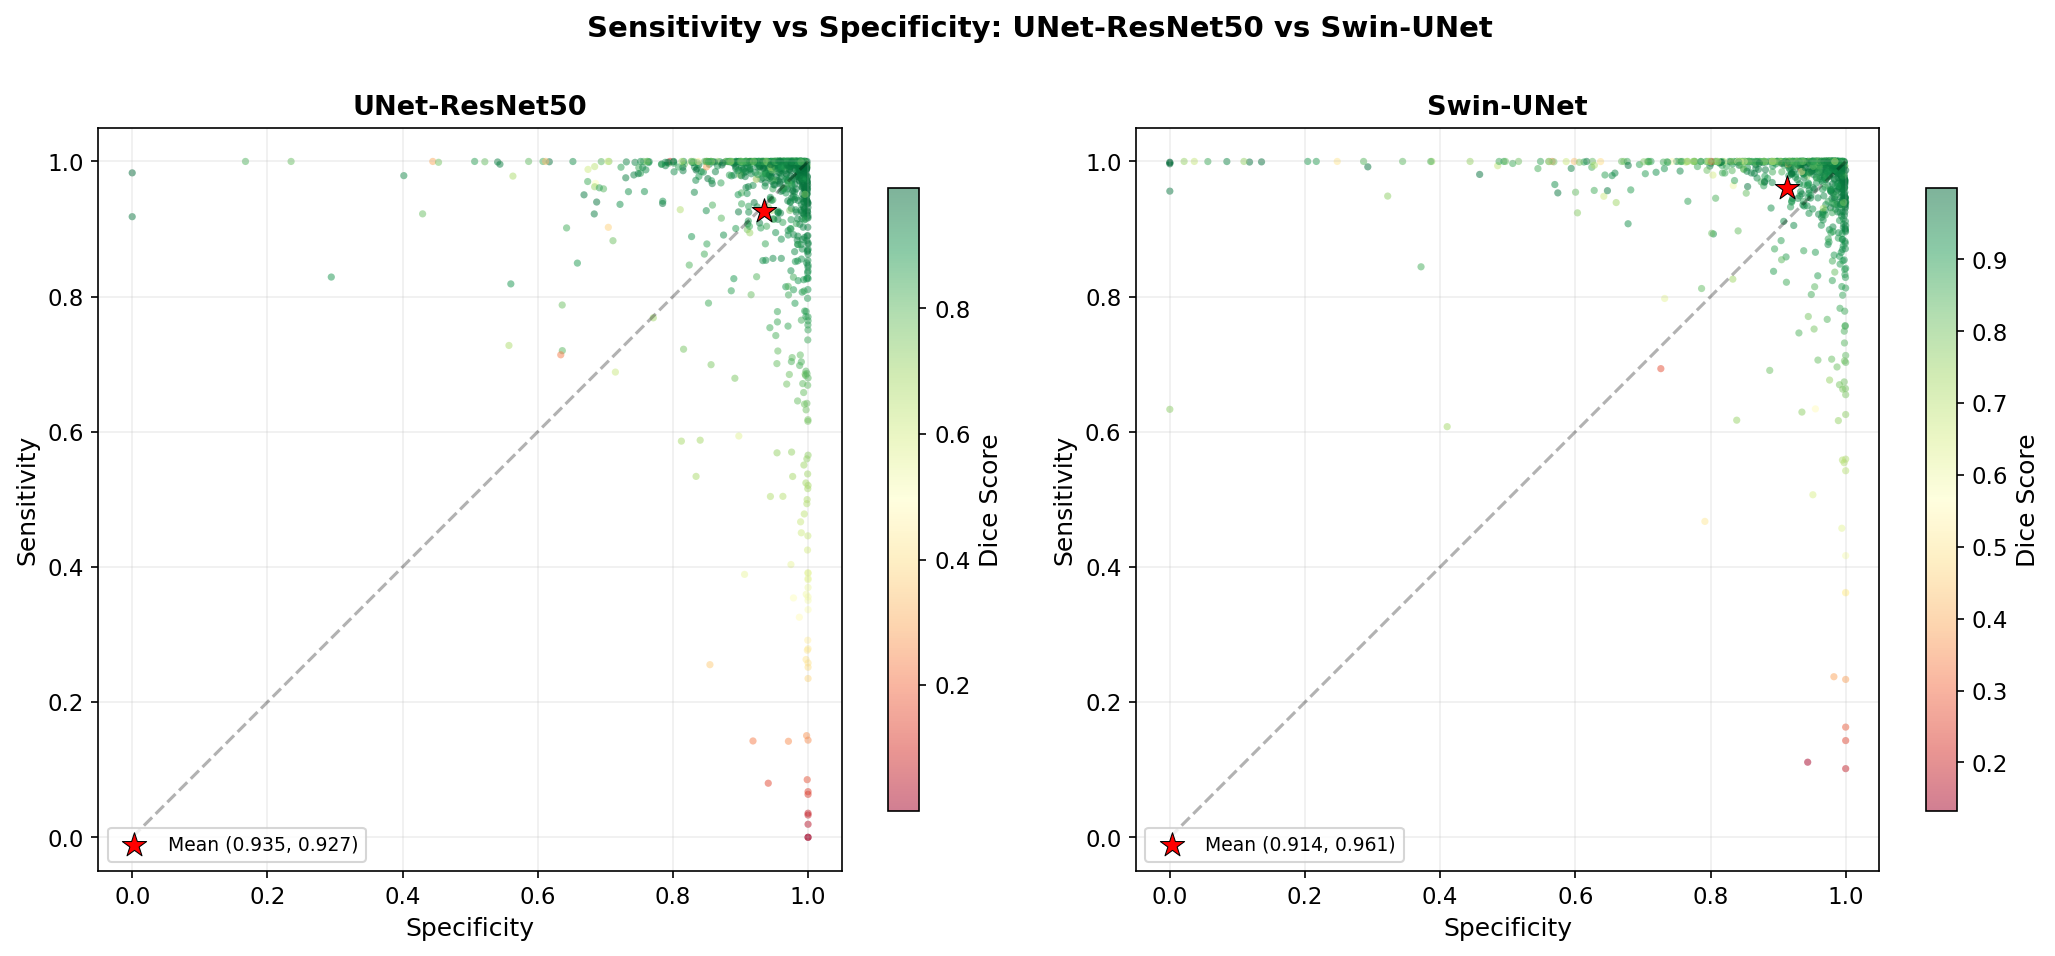

In [13]:
# --- Sensitivity vs Specificity ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, m, color, title in [
    (axes[0], unet, C_UNET, 'UNet-ResNet50'),
    (axes[1], swin, C_SWIN, 'Swin-UNet'),
]:
    df = m['df_samples']
    metrics = m['eval_data']['aggregated_metrics']

    sc = ax.scatter(df['specificity'], df['sensitivity'],
                    c=df['dice'], cmap='RdYlGn', s=12, alpha=0.5, edgecolors='none')
    plt.colorbar(sc, ax=ax, shrink=0.8, label='Dice Score')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.scatter(metrics['specificity'], metrics['sensitivity'],
               c='red', s=150, marker='*', zorder=5, edgecolors='black', linewidths=0.5,
               label=f"Mean ({metrics['specificity']:.3f}, {metrics['sensitivity']:.3f})")

    ax.set_xlabel('Specificity')
    ax.set_ylabel('Sensitivity')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.legend(loc='lower left', fontsize=9, frameon=True)
    ax.grid(True, alpha=0.2)

plt.suptitle('Sensitivity vs Specificity: UNet-ResNet50 vs Swin-UNet',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / '08_sens_vs_spec.png')
plt.show()

---
## 8. Phan Tich Tung Mau: Mo Hinh Nao Tot Hon?

So sanh Dice Score tren tung mau: bao nhieu mau Swin-UNet thang, bao nhieu mau UNet-ResNet50 thang.

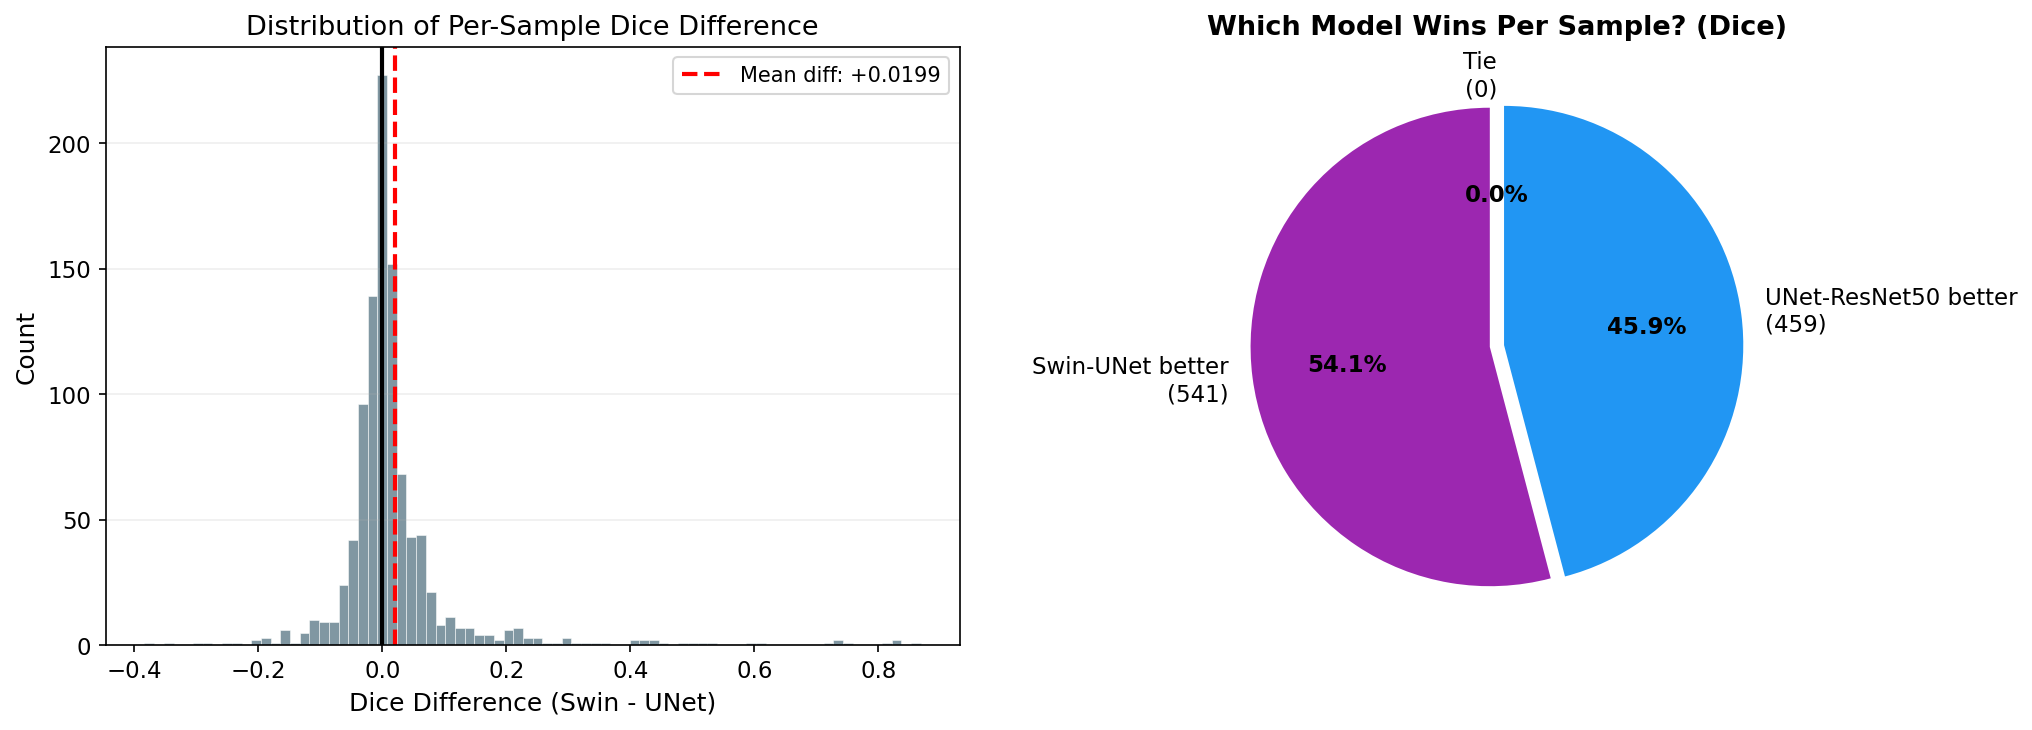

Swin-UNet wins  : 541 samples (54.1%)
UNet-ResNet50 wins: 459 samples (45.9%)
Ties             : 0 samples
Mean difference  : +0.0199
Median difference: +0.0021


In [14]:
# --- Per-Sample Difference Analysis ---
dice_diff = swin['df_samples']['dice'].values - unet['df_samples']['dice'].values

swin_wins = (dice_diff > 0).sum()
unet_wins = (dice_diff < 0).sum()
ties = (dice_diff == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of differences
ax = axes[0]
ax.hist(dice_diff, bins=80, color='#607D8B', edgecolor='white', alpha=0.8, linewidth=0.3)
ax.axvline(x=0, color='black', linewidth=2, linestyle='-')
ax.axvline(x=np.mean(dice_diff), color='red', linewidth=2, linestyle='--',
           label=f'Mean diff: {np.mean(dice_diff):+.4f}')
ax.set_xlabel('Dice Difference (Swin - UNet)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Per-Sample Dice Difference')
ax.legend(fontsize=10, frameon=True)
ax.grid(True, alpha=0.2, axis='y')

# Pie chart
ax = axes[1]
sizes = [swin_wins, unet_wins, ties]
labels_pie = [f'Swin-UNet better\n({swin_wins})', f'UNet-ResNet50 better\n({unet_wins})', f'Tie\n({ties})']
colors_pie = [C_SWIN, C_UNET, '#BDBDBD']
explode = (0.03, 0.03, 0.03)

wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors_pie,
                                    explode=explode, autopct='%1.1f%%',
                                    startangle=90, pctdistance=0.6,
                                    textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('Which Model Wins Per Sample? (Dice)', fontsize=13, fontweight='bold')

plt.tight_layout()
fig.savefig(REPORT_DIR / '09_per_sample_diff.png')
plt.show()

print(f'Swin-UNet wins  : {swin_wins} samples ({swin_wins/len(dice_diff)*100:.1f}%)')
print(f'UNet-ResNet50 wins: {unet_wins} samples ({unet_wins/len(dice_diff)*100:.1f}%)')
print(f'Ties             : {ties} samples')
print(f'Mean difference  : {np.mean(dice_diff):+.4f}')
print(f'Median difference: {np.median(dice_diff):+.4f}')

---
## 9. Phan Tich Truong Hop That Bai

So sanh ty le mau co Dice thap giua hai mo hinh.

In [15]:
# --- Failure Rate Comparison ---
thresholds = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9]

rows = []
for t in thresholds:
    u_count = (unet['df_samples']['dice'] < t).sum()
    s_count = (swin['df_samples']['dice'] < t).sum()
    n = len(unet['df_samples'])
    rows.append({
        'Threshold': f'Dice < {t}',
        'UNet-ResNet50': f'{u_count} ({u_count/n*100:.1f}%)',
        'Swin-UNet': f'{s_count} ({s_count/n*100:.1f}%)',
        'Fewer Failures': 'Swin-UNet' if s_count < u_count else ('UNet-ResNet50' if u_count < s_count else 'Tie'),
    })

# Add >= 0.9 (success rate)
u_high = (unet['df_samples']['dice'] >= 0.9).sum()
s_high = (swin['df_samples']['dice'] >= 0.9).sum()
n = len(unet['df_samples'])
rows.append({
    'Threshold': f'Dice ≥ 0.9 (great)',
    'UNet-ResNet50': f'{u_high} ({u_high/n*100:.1f}%)',
    'Swin-UNet': f'{s_high} ({s_high/n*100:.1f}%)',
    'Fewer Failures': 'Swin-UNet' if s_high > u_high else ('UNet-ResNet50' if u_high > s_high else 'Tie'),
})

df_fail = pd.DataFrame(rows)
styled = df_fail.style.map(color_winner, subset=['Fewer Failures']) \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#37474F'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ]).hide(axis='index')

display(HTML('<h3>Failure Rate Comparison</h3>'))
display(styled)

Threshold,UNet-ResNet50,Swin-UNet,Fewer Failures
Dice < 0.1,6 (0.6%),0 (0.0%),Swin-UNet
Dice < 0.3,17 (1.7%),7 (0.7%),Swin-UNet
Dice < 0.5,32 (3.2%),14 (1.4%),Swin-UNet
Dice < 0.7,80 (8.0%),42 (4.2%),Swin-UNet
Dice < 0.8,155 (15.5%),112 (11.2%),Swin-UNet
Dice < 0.9,402 (40.2%),382 (38.2%),Swin-UNet
Dice ≥ 0.9 (great),598 (59.8%),618 (61.8%),Swin-UNet


---
## 10. Ket Luan Tong Quan

### Bang tom tat:

| Tieu chi | UNet-ResNet50 | Swin-UNet | Nhan xet |
|---|---|---|---|
| **Kien truc** | CNN (Encoder-Decoder) | Vision Transformer | Hai huong tiep can khac nhau |
| **Best Val Dice** | (xem bang tren) | (xem bang tren) | So sanh tu ket qua |
| **Toc do train** | Nhanh hon | Cham hon | Transformer ton nhieu bo nho va tinh toan |
| **Overfitting** | Co xu huong overfit | On dinh hon | Transformer co self-attention regularize tot hon |
| **Global Context** | Han che (local receptive field) | Tot (self-attention) | Loi the chinh cua Transformer |

### Ket luan:
1. **Swin-UNet** tan dung kha nang **global self-attention** cua Vision Transformer, giup nhan dien cac dac trung toan cuc tot hon — dac biet huu ich cho phan vung ton thuong da co hinh dang va kich thuoc da dang.
2. **UNet-ResNet50** van la lua chon tot voi **toc do huan luyen nhanh hon** va ket qua canh tranh, phu hop khi tai nguyen tinh toan han che.
3. Ca hai mo hinh deu dat **Dice > 85%** — nguong duoc coi la co do chinh xac cao va kha thi cho ung dung thuc te.
4. Viec ket hop (**ensemble**) hai mo hinh co the cho ket qua tot hon nua, vi chung co cac diem manh bo sung cho nhau.

In [16]:
# --- Final: List all saved report files ---
print('=' * 50)
print('  COMPARISON REPORT FILES')
print('=' * 50)
for f in sorted(REPORT_DIR.glob('*.png')):
    print(f'  {f.name}')
print('=' * 50)
print(f'  Location: {REPORT_DIR}')
print('  Tip: File > Export as PDF to save this notebook')

  COMPARISON REPORT FILES
  01_loss_comparison.png
  02_dice_iou_comparison.png
  03_training_time.png
  04_metrics_comparison.png
  05_radar_chart.png
  06_distributions.png
  07_boxplots.png
  08_sens_vs_spec.png
  09_per_sample_diff.png
  Location: C:\Users\yello\Coding\Python\Projects\Deep Learning\Skin-Lesion-Segmentation\reports\comparison
  Tip: File > Export as PDF to save this notebook
